In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

In [2]:
EVAL_PATH = "results/testing/2026_04_25__13_13_32_batch_pipeline_testing_with_no_augmentation_with_ufld_model/evaluation.json"

FOLDER_PATH = EVAL_PATH.rsplit("/", 1)[0] + "/"

RESULTS_FILE = f"{FOLDER_PATH}/results.txt"


In [3]:
## Loading the data
with open(EVAL_PATH) as f:
    data = json.load(f)

In [4]:
accuracy  = np.array([d['accuracy']  for d in data])
fp        = np.array([d['fp']        for d in data])
fn        = np.array([d['fn']        for d in data])
run_time  = np.array([d['run_time']  for d in data])
clips     = [Path(d['raw_file']).parts[2] if len(Path(d['raw_file']).parts) > 2 else str(i)
             for i, d in enumerate(data)]
indices   = np.arange(len(data))

In [5]:
print(accuracy.mean())

0.6994107142857143


In [6]:
output = "\n".join([
    f"Loaded {len(data)} samples",
    f"Accuracy  — mean: {accuracy.mean():.4f}  std: {accuracy.std():.4f}  min: {accuracy.min():.4f}  max: {accuracy.max():.4f}",
    f"FP        — mean: {fp.mean():.4f}  std: {fp.std():.4f}  min: {fp.min():.4f}  max: {fp.max():.4f}",
    f"FN        — mean: {fn.mean():.4f}  std: {fn.std():.4f}  min: {fn.min():.4f}  max: {fn.max():.4f}",
    f"Run-time  — mean: {run_time.mean()*1000:.2f} ms  std: {run_time.std()*1000:.2f} ms  min: {run_time.min()*1000:.2f} ms  max: {run_time.max()*1000:.2f} ms",
])

print(output)


with open(RESULTS_FILE, "a") as f:
    f.write(output + "\n")

Loaded 500 samples
Accuracy  — mean: 0.6994  std: 0.1105  min: 0.3095  max: 0.9762
FP        — mean: 0.1840  std: 0.2801  min: 0.0000  max: 1.0000
FN        — mean: 0.4452  std: 0.2023  min: 0.0000  max: 1.0000
Run-time  — mean: 255.82 ms  std: 123.64 ms  min: 193.49 ms  max: 1385.20 ms


In [7]:
# ── Styling ───────────────────────────────────────────────────────────────────
plt.rcParaupdate({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3144',
    'axes.labelcolor':  '#c8ccd8',
    'axes.grid':        True,
    'grid.color':       '#2e3144',
    'grid.linewidth':   0.6,
    'xtick.color':      '#7a7f99',
    'ytick.color':      '#7a7f99',
    'text.color':       '#c8ccd8',
    'font.family':      'monospace',
})

C_ACC  = '#4fc3f7'   # sky blue
C_FP   = '#ef5350'   # red
C_FN   = '#ff8a65'   # orange
C_TIME = '#a5d6a7'   # green

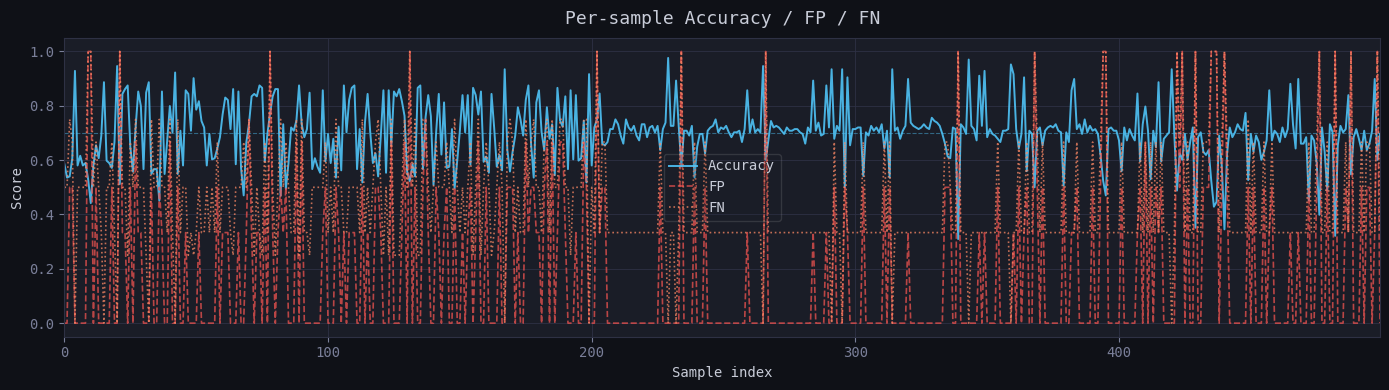

In [8]:
# ── 1. Per-sample line chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#0f1117')

ax.plot(indices, accuracy, color=C_ACC,  lw=1.4, label='Accuracy', alpha=0.9)
ax.plot(indices, fp,       color=C_FP,   lw=1.2, label='FP',       alpha=0.75, linestyle='--')
ax.plot(indices, fn,       color=C_FN,   lw=1.2, label='FN',       alpha=0.75, linestyle=':')

ax.axhline(accuracy.mean(), color=C_ACC, lw=0.8, linestyle='--', alpha=0.45)
ax.set_xlabel('Sample index')
ax.set_ylabel('Score')
ax.set_title('Per-sample Accuracy / FP / FN', fontsize=13, pad=10)
ax.legend(framealpha=0.15)
ax.set_xlim(0, len(data) - 1)
plt.tight_layout()
plt.savefig(FOLDER_PATH + 'per_sample_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

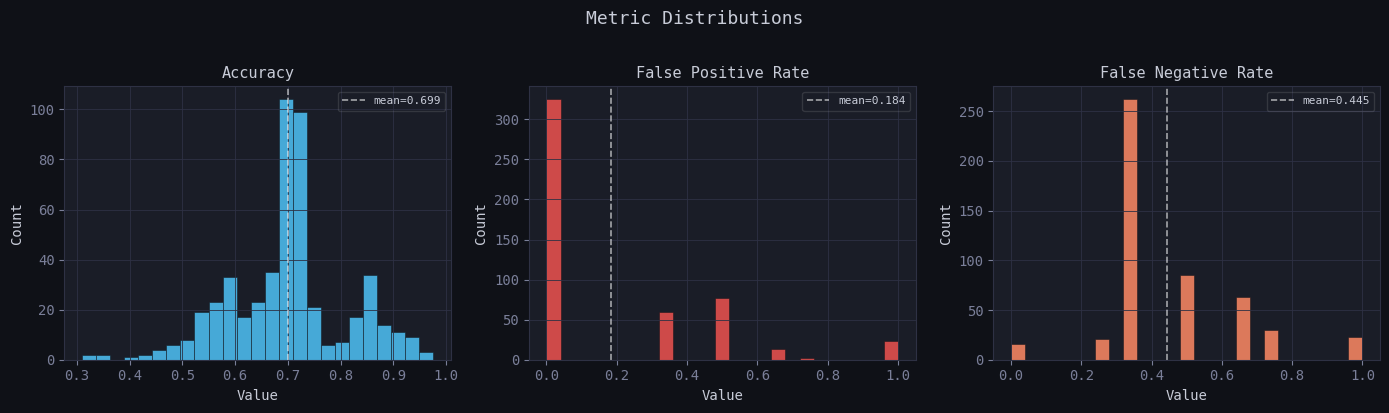

In [9]:
# ── 2. Distributions (histograms) ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor('#0f1117')

specs = [
    (accuracy, C_ACC, 'Accuracy'),
    (fp,       C_FP,  'False Positive Rate'),
    (fn,       C_FN,  'False Negative Rate'),
]

for ax, (arr, color, label) in zip(axes, specs):
    ax.hist(arr, bins=25, color=color, alpha=0.85, edgecolor='#0f1117', linewidth=0.4)
    ax.axvline(arr.mean(), color='white', lw=1.2, linestyle='--', alpha=0.6, label=f'mean={arr.mean():.3f}')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8, framealpha=0.15)

fig.suptitle('Metric Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FOLDER_PATH + 'metric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

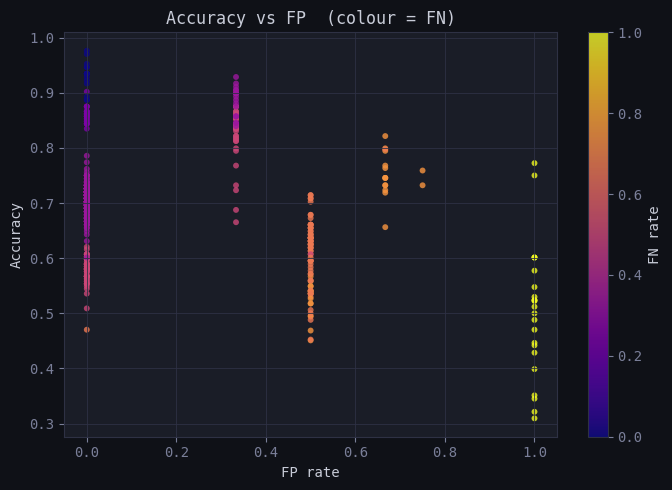

In [10]:
# ── 3. Scatter: Accuracy vs FP coloured by FN ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#0f1117')

sc = ax.scatter(fp, accuracy, c=fn, cmap='plasma', s=18, alpha=0.8, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('FN rate', color='#c8ccd8')
cbar.ax.yaxis.set_tick_params(color='#7a7f99')

ax.set_xlabel('FP rate')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs FP  (colour = FN)', fontsize=12)
plt.tight_layout()
plt.savefig(FOLDER_PATH + 'scatter_acc_fp_fn.png', dpi=150, bbox_inches='tight')
plt.show()

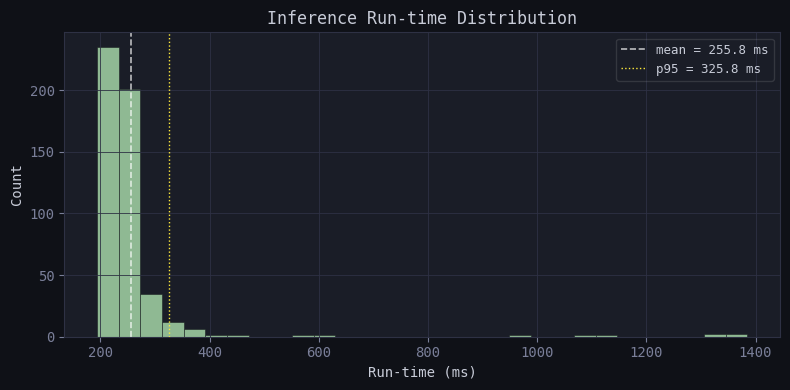

In [11]:
# ── 4. Run-time distribution ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#0f1117')

rt_ms = run_time * 1000
ax.hist(rt_ms, bins=30, color=C_TIME, alpha=0.85, edgecolor='#0f1117', linewidth=0.4)
ax.axvline(rt_mean(), color='white', lw=1.2, linestyle='--', alpha=0.7,
           label=f'mean = {rt_mean():.1f} ms')
ax.axvline(np.percentile(rt_ms, 95), color='#ffeb3b', lw=1.0, linestyle=':',
           label=f'p95 = {np.percentile(rt_ms, 95):.1f} ms')

ax.set_xlabel('Run-time (ms)')
ax.set_ylabel('Count')
ax.set_title('Inference Run-time Distribution', fontsize=12)
ax.legend(fontsize=9, framealpha=0.15)
plt.tight_layout()
plt.savefig(FOLDER_PATH + 'runtime_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── 5. Summary stats table ────────────────────────────────────────────────────
metrics = {'Accuracy': accuracy, 'FP': fp, 'FN': fn, 'Run-time (ms)': rt_ms}
header  = f"{'Metric':<18} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'p25':>8} {'Median':>8} {'p75':>8}"
print(header)
print('-' * len(header))
for name, arr in metrics.items():
    print(f"{name:<18} {arr.mean():>8.4f} {arr.std():>8.4f} {arr.min():>8.4f} "
          f"{arr.max():>8.4f} {np.percentile(arr,25):>8.4f} "
          f"{np.median(arr):>8.4f} {np.percentile(arr,75):>8.4f}")

Metric                 Mean      Std      Min      Max      p25   Median      p75
---------------------------------------------------------------------------------
Accuracy             0.6994   0.1105   0.3095   0.9762   0.6369   0.7083   0.7321
FP                   0.1840   0.2801   0.0000   1.0000   0.0000   0.0000   0.3333
FN                   0.4452   0.2023   0.0000   1.0000   0.3333   0.3333   0.5000
Run-time (ms)      255.8238 123.6375 193.4884 1385.2024 218.6202 235.6156 254.4361


In [13]:
# ── 6. Worst / best samples ───────────────────────────────────────────────────
n = 5
worst = sorted(data, key=lambda d: d['accuracy'])[:n]
best  = sorted(data, key=lambda d: d['accuracy'], reverse=True)[:n]

lines = [
    f"\n{'─'*60}",
    f"  TOP {n} WORST samples (lowest accuracy)",
    f"{'─'*60}",
    *[f"  acc={d['accuracy']:.4f}  fp={d['fp']:.3f}  fn={d['fn']:.3f}  {d['raw_file']}" for d in worst],
    f"\n{'─'*60}",
    f"  TOP {n} BEST samples (highest accuracy)",
    f"{'─'*60}",
    *[f"  acc={d['accuracy']:.4f}  fp={d['fp']:.3f}  fn={d['fn']:.3f}  {d['raw_file']}" for d in best],
]

output = "\n".join(lines)
print(output)

with open(RESULTS_FILE, "a") as f:
    f.write(output + "\n")


────────────────────────────────────────────────────────────
  TOP 5 WORST samples (lowest accuracy)
────────────────────────────────────────────────────────────
  acc=0.3095  fp=1.000  fn=1.000  test_set/clips/0530/1492628379939575351_0/20.jpg
  acc=0.3214  fp=1.000  fn=1.000  test_set/clips/0530/1492628557232252737_0/20.jpg
  acc=0.3452  fp=1.000  fn=1.000  test_set/clips/0530/1492628447299511407_0/20.jpg
  acc=0.3512  fp=1.000  fn=1.000  test_set/clips/0530/1492628545240318854_0/20.jpg
  acc=0.3988  fp=1.000  fn=1.000  test_set/clips/0530/1492628437305491167_0/20.jpg

────────────────────────────────────────────────────────────
  TOP 5 BEST samples (highest accuracy)
────────────────────────────────────────────────────────────
  acc=0.9762  fp=0.000  fn=0.000  test_set/clips/0530/1492627507467762037_0/20.jpg
  acc=0.9702  fp=0.000  fn=0.000  test_set/clips/0530/1492627509466736747_0/20.jpg
  acc=0.9524  fp=0.000  fn=0.000  test_set/clips/0530/1492627491479844617_0/20.jpg
  acc=0.94

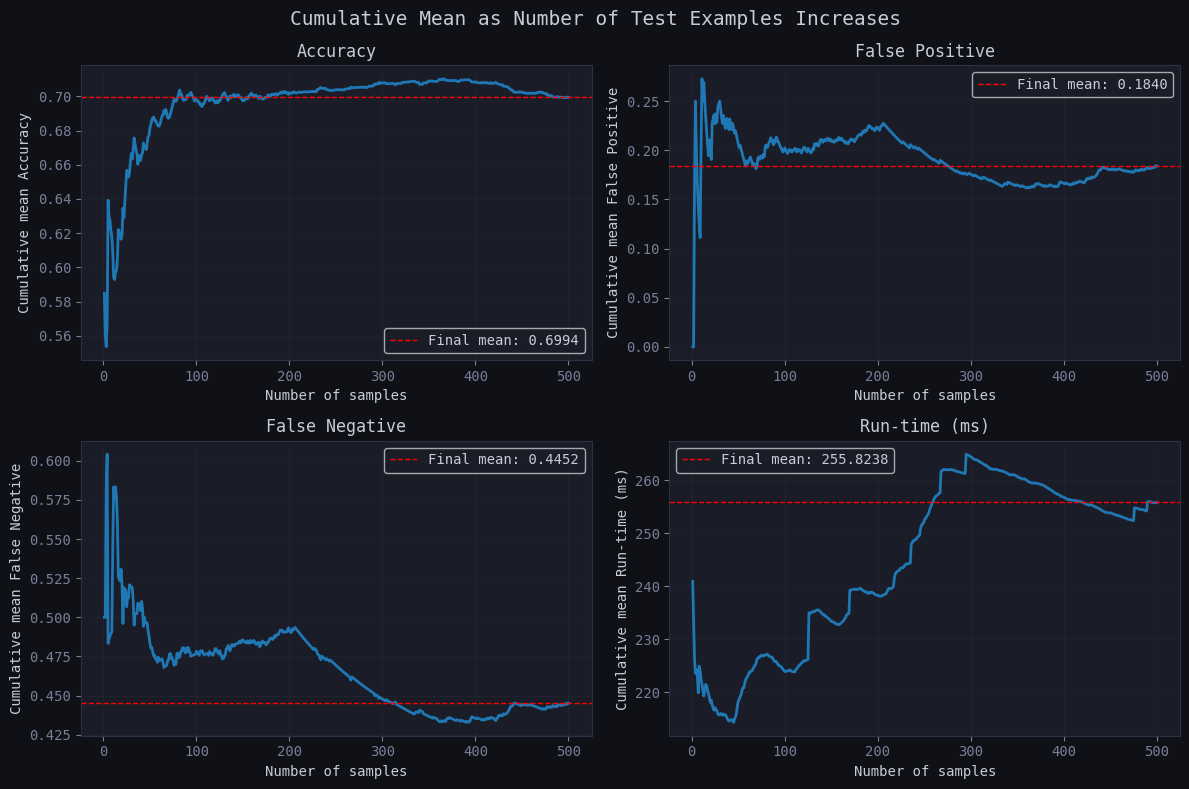

Graph saved to results/testing/2026_04_25__13_13_32_batch_pipeline_testing_with_no_augmentation_with_ufld_model//cumulative_mean.png


In [14]:
# ── Cumulative mean plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Cumulative Mean as Number of Test Examples Increases", fontsize=14)

metrics = [
    (accuracy,          "Accuracy",      axes[0, 0]),
    (fp,                "False Positive", axes[0, 1]),
    (fn,                "False Negative", axes[1, 0]),
    (run_time * 1000,   "Run-time (ms)", axes[1, 1]),
]

for values, label, ax in metrics:
    cumulative_mean = np.cumsum(values) / np.arange(1, len(values) + 1)
    ax.plot(indices + 1, cumulative_mean, linewidth=2)
    ax.axhline(values.mean(), color='red', linestyle='--', linewidth=1, label=f"Final mean: {values.mean():.4f}")
    ax.set_title(label)
    ax.set_xlabel("Number of samples")
    ax.set_ylabel(f"Cumulative mean {label}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()

GRAPH_PATH = f"{FOLDER_PATH}/cumulative_mean.png"
plt.savefig(GRAPH_PATH, dpi=150)
plt.show()
print(f"Graph saved to {GRAPH_PATH}")